In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Set the random seed for reproducibility
np.random.seed(42)

In [ ]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [ ]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [ ]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


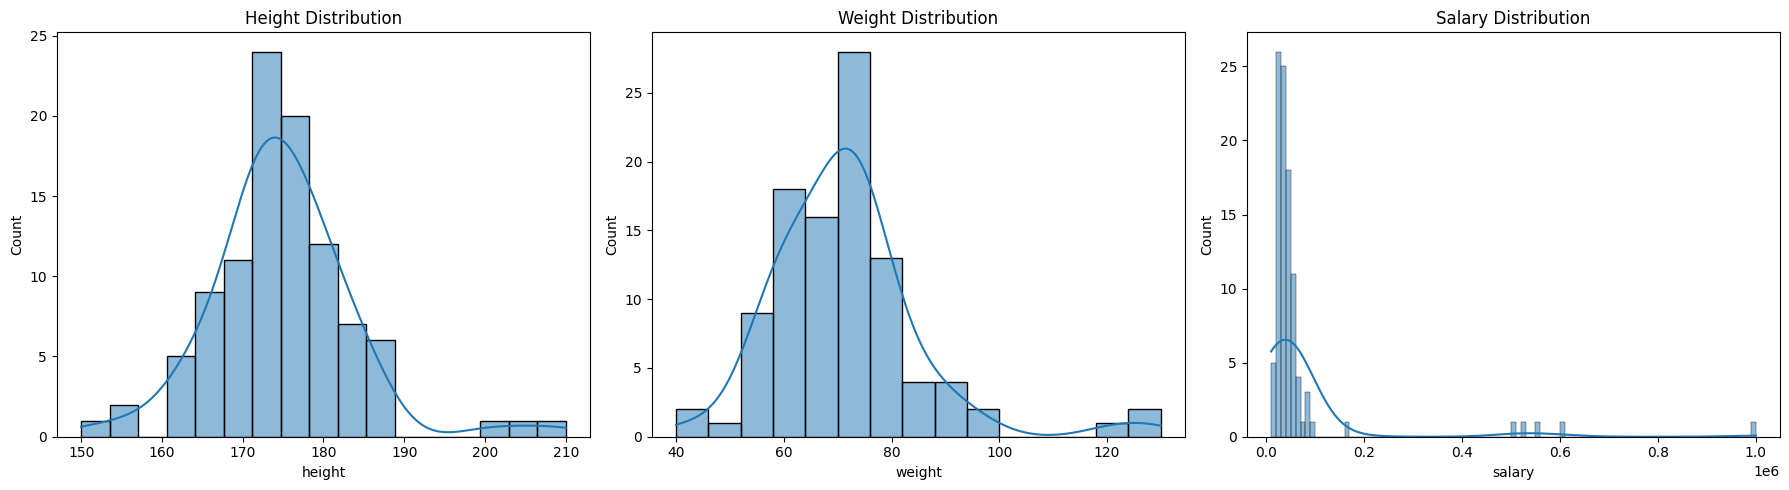

In [ ]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

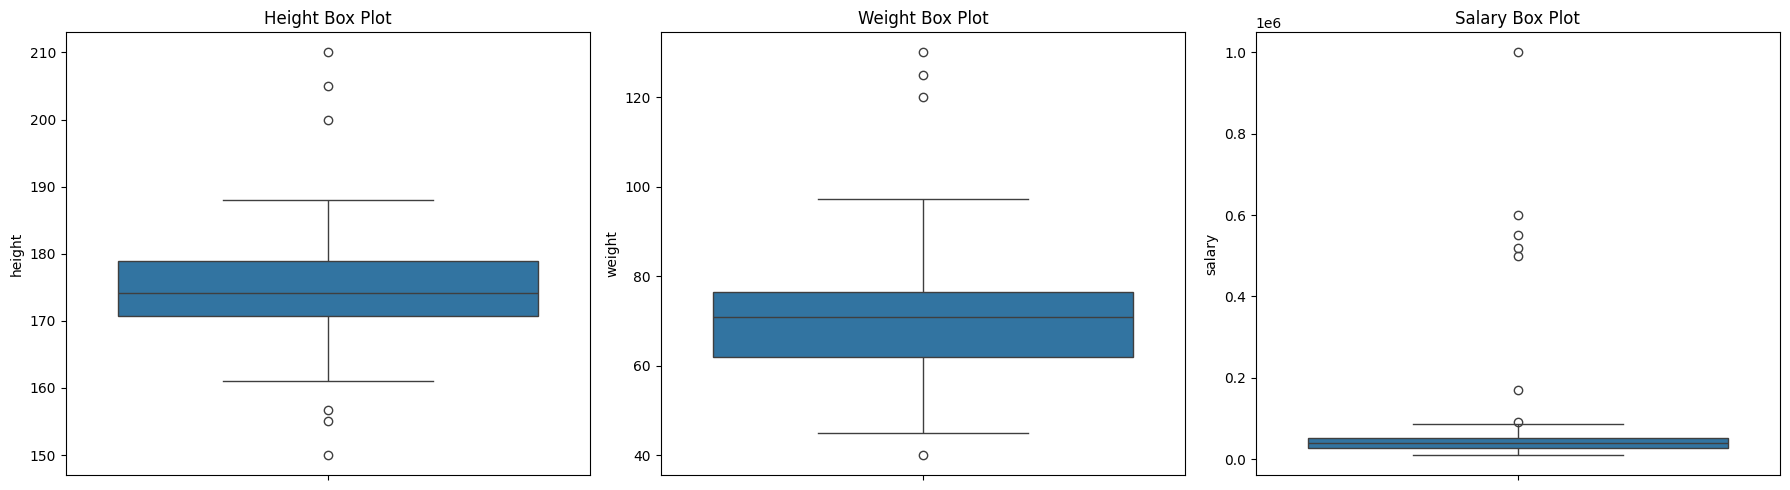

In [ ]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

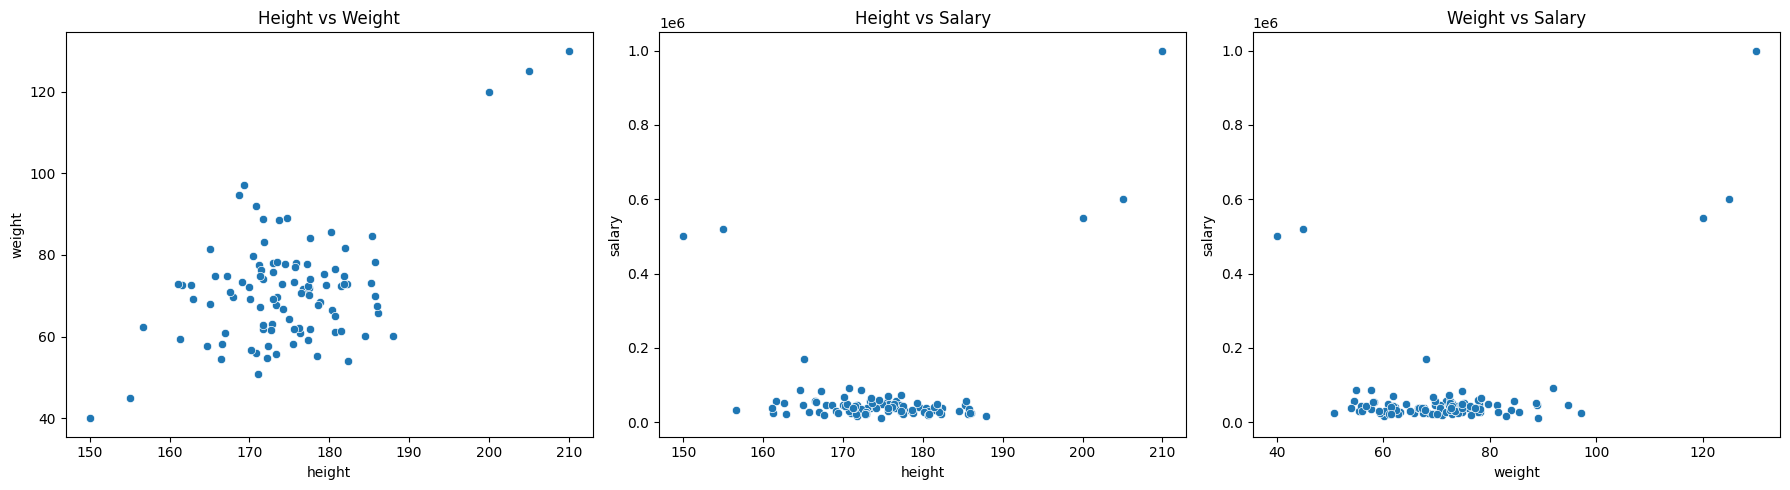

In [ ]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [ ]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [ ]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [ ]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [ ]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


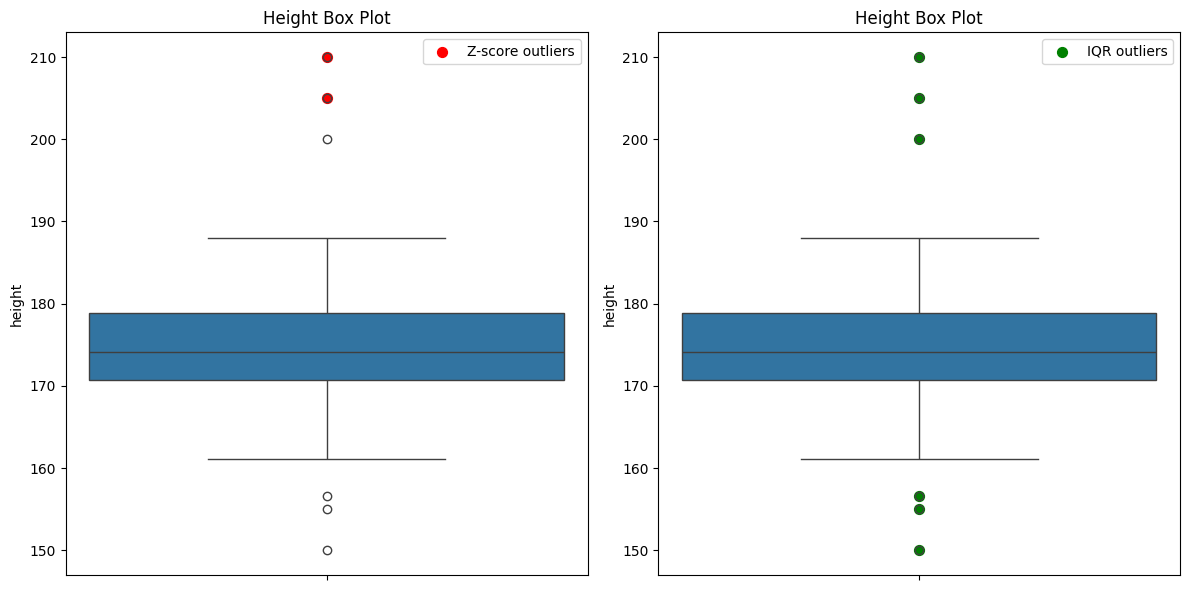

In [ ]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [ ]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [ ]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [ ]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


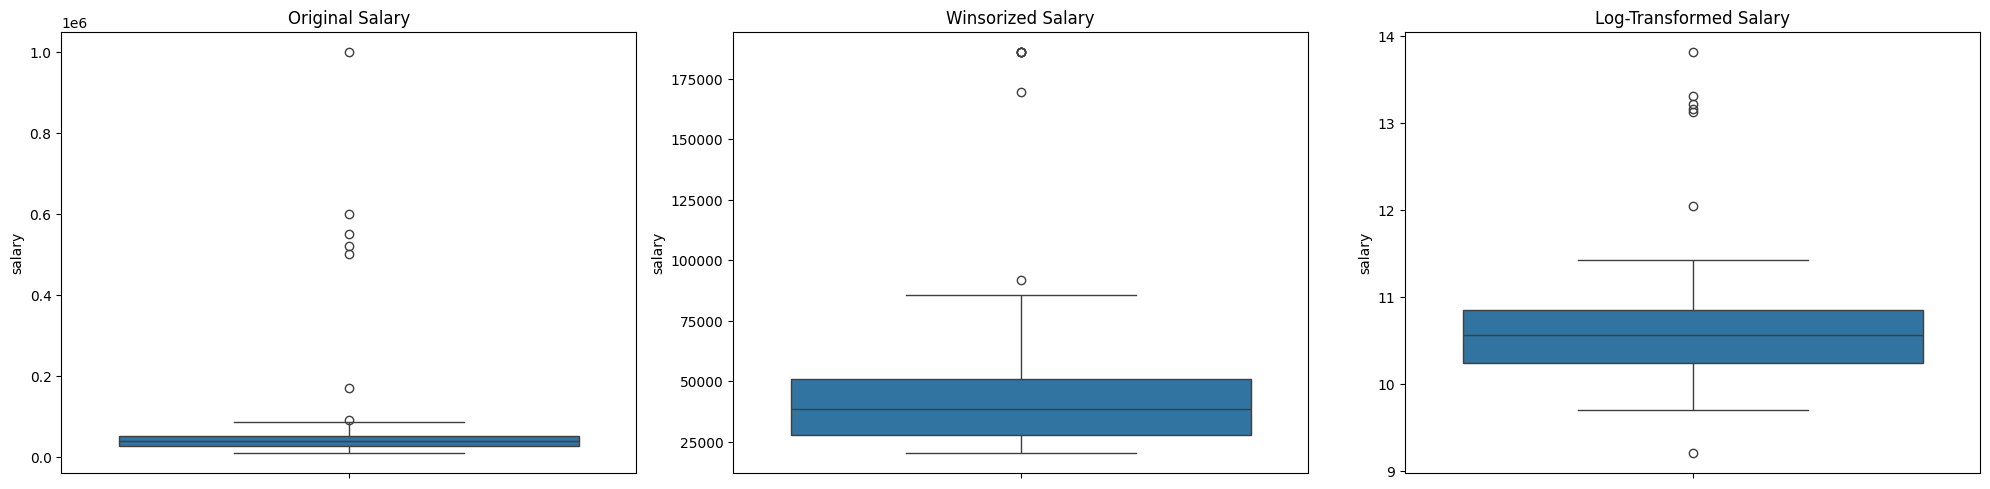

In [ ]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [ ]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


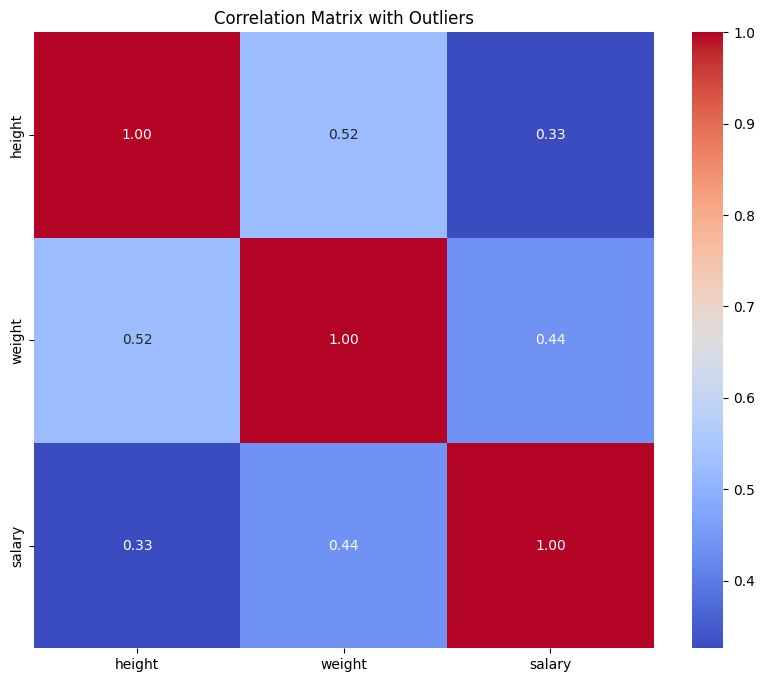

In [ ]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


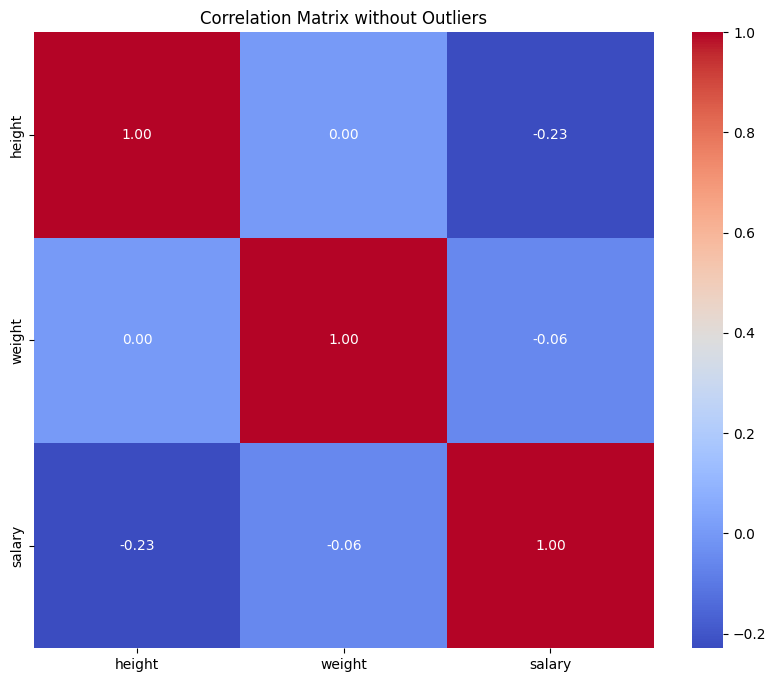

In [ ]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [ ]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [ ]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [ ]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [ ]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


Multivariate outliers: 0 found at indices []


<Figure size 1200x1000 with 0 Axes>

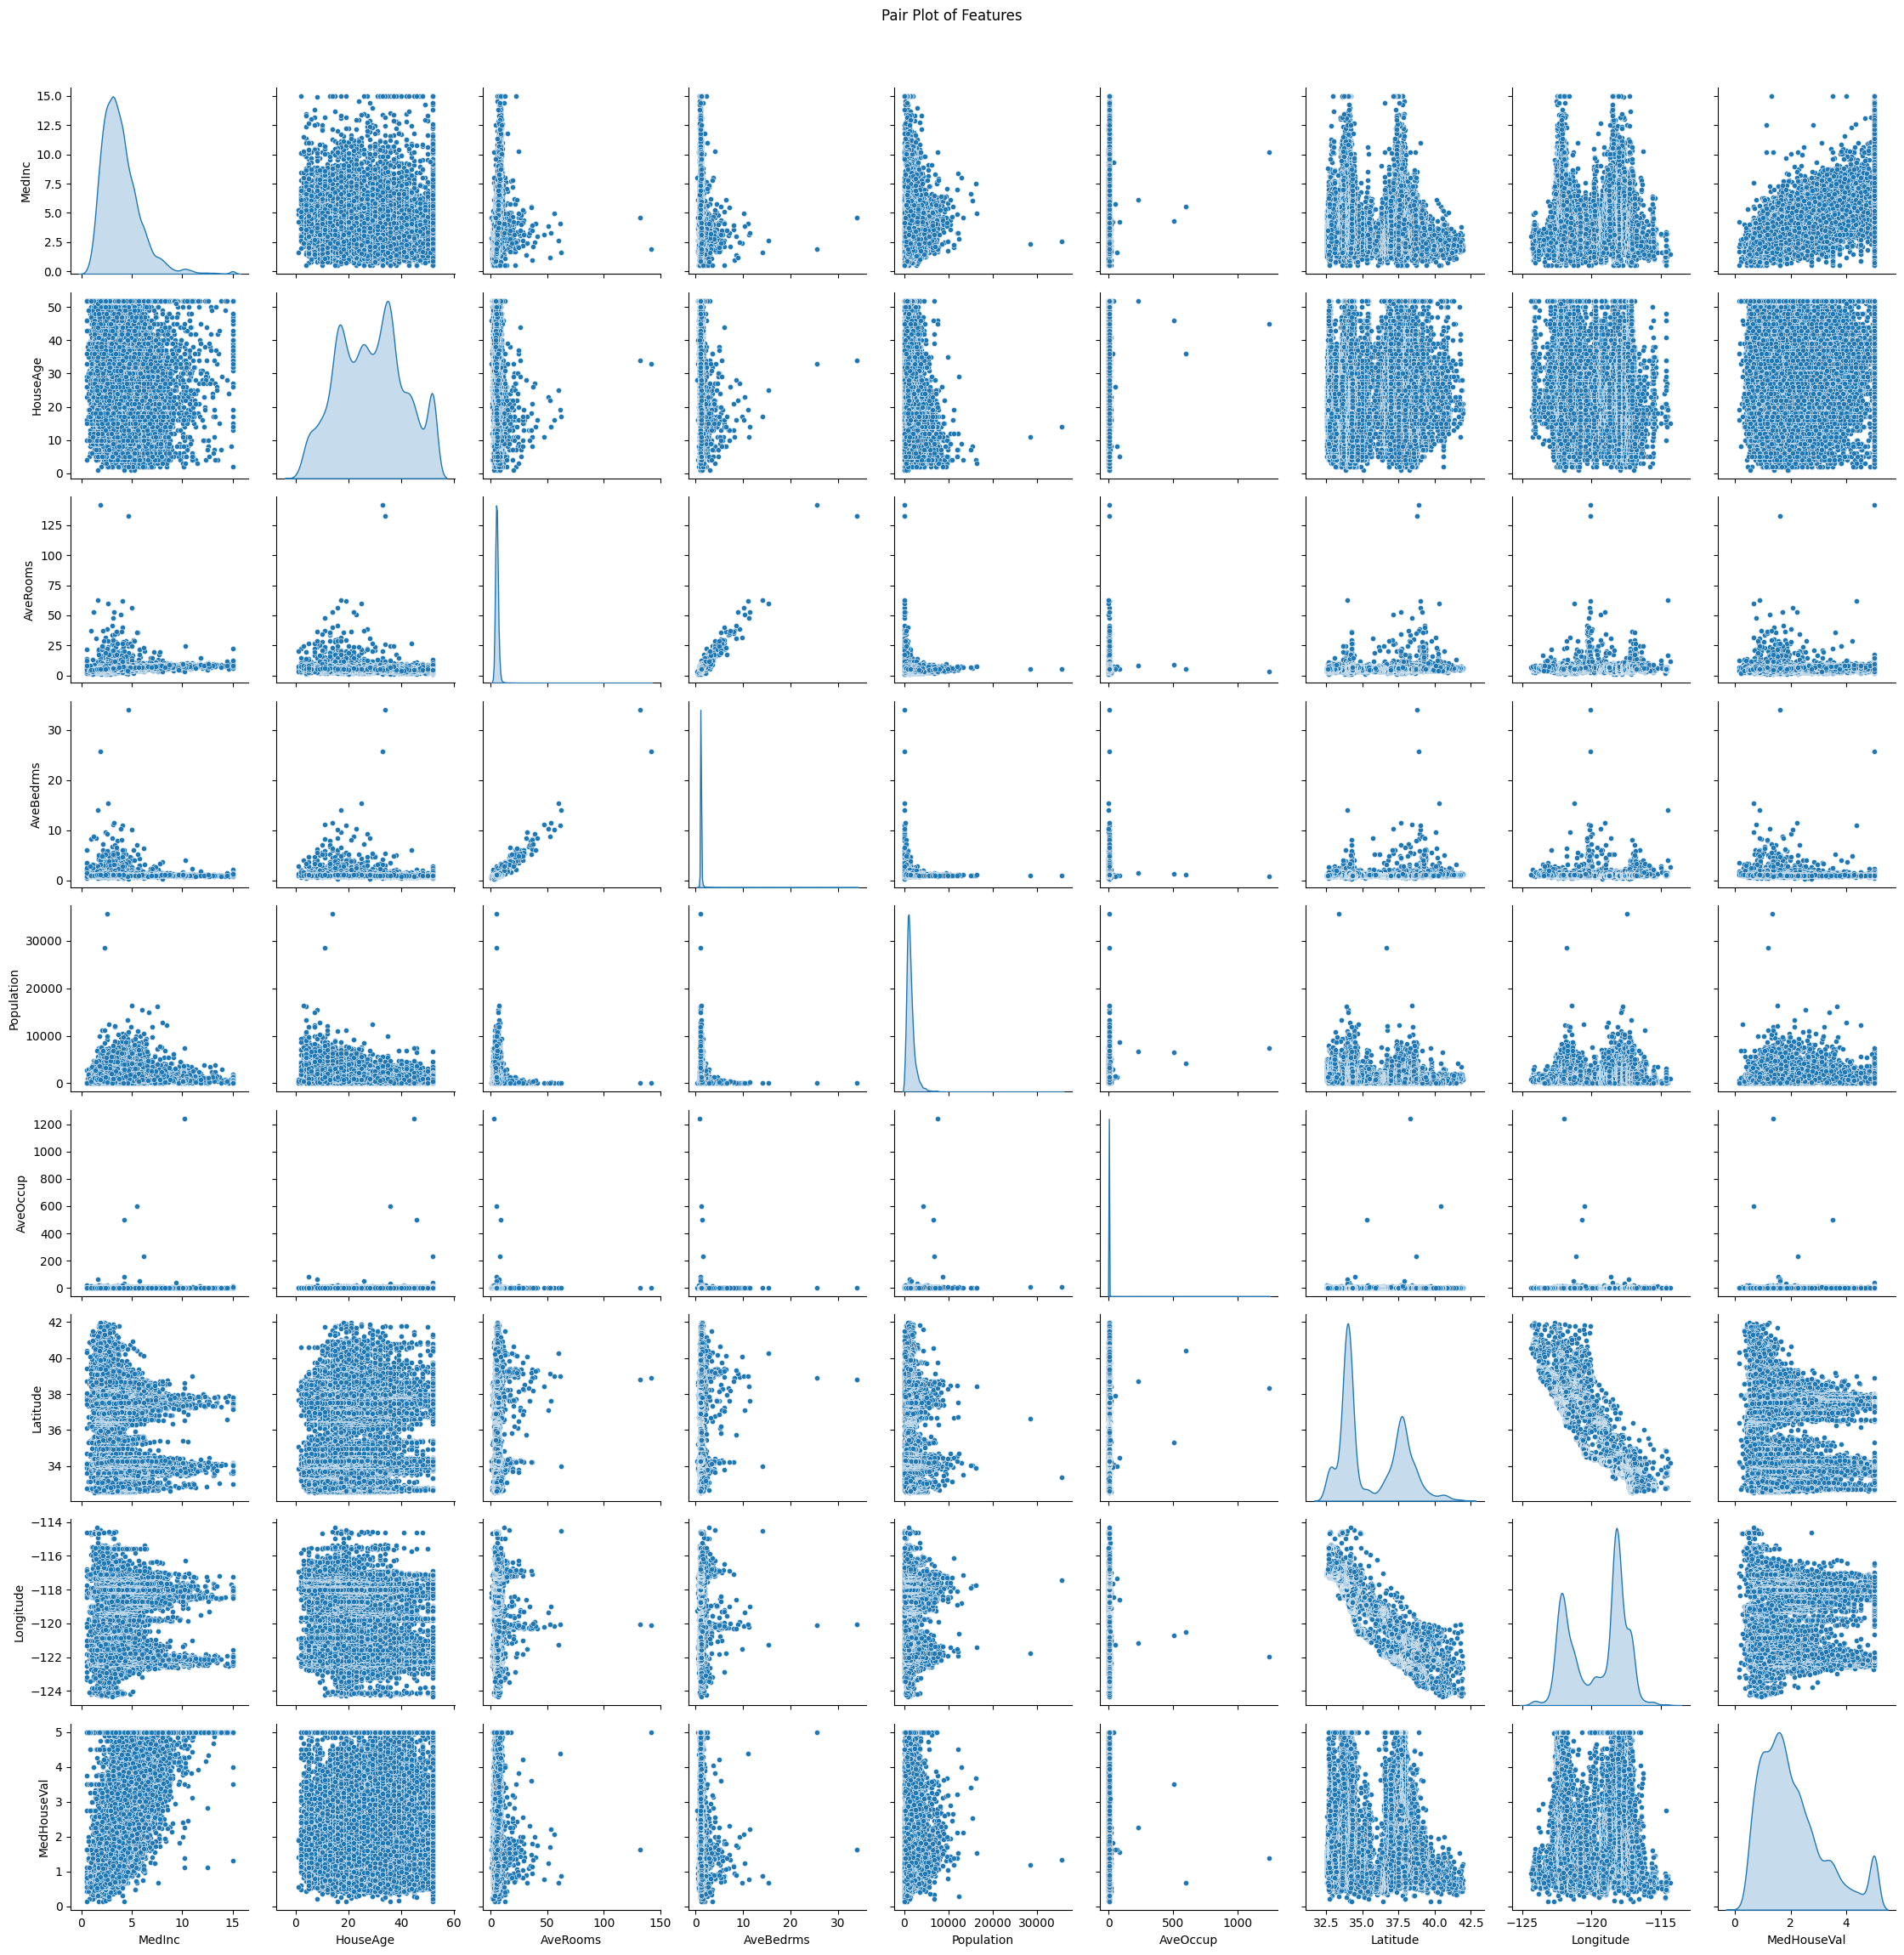

In [ ]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2556/3117540217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


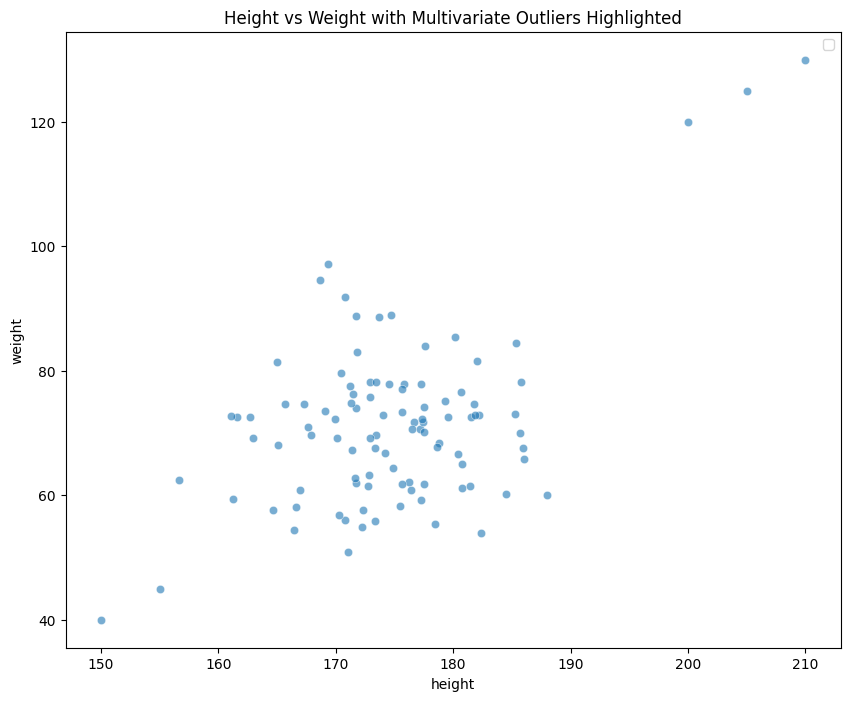

In [ ]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


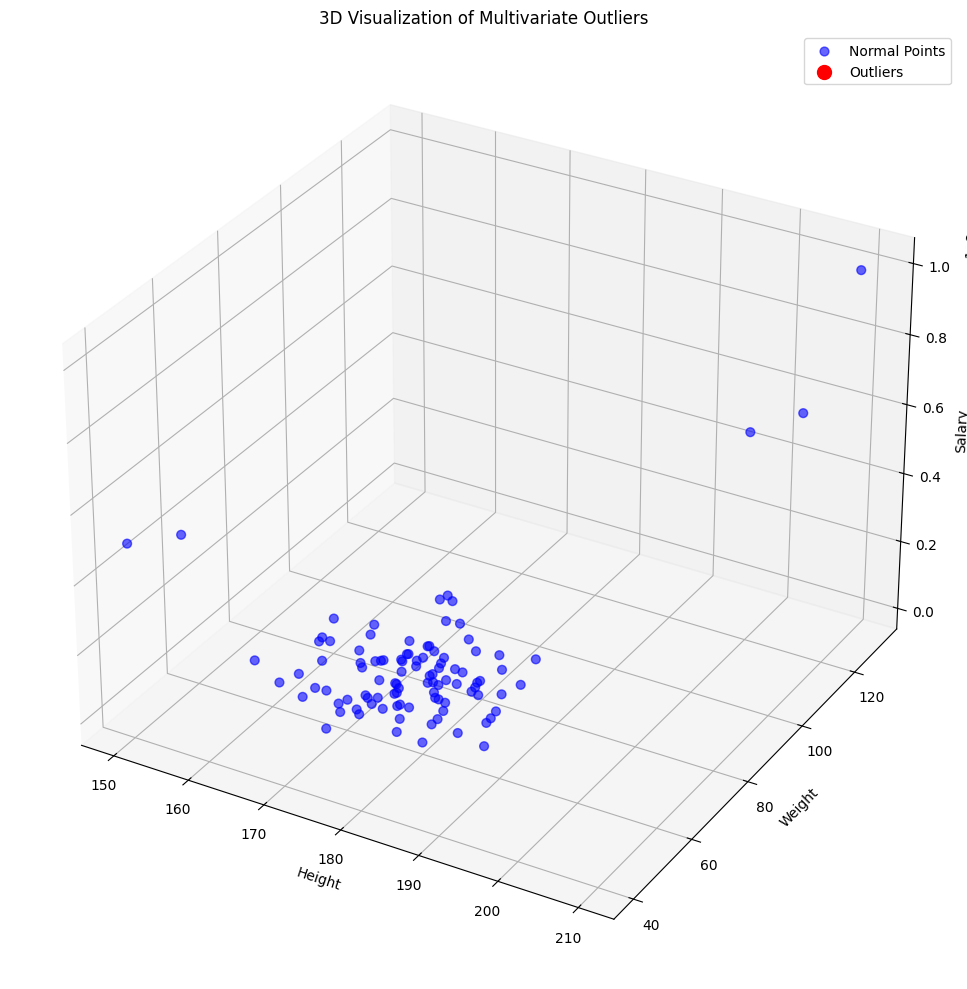

In [ ]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


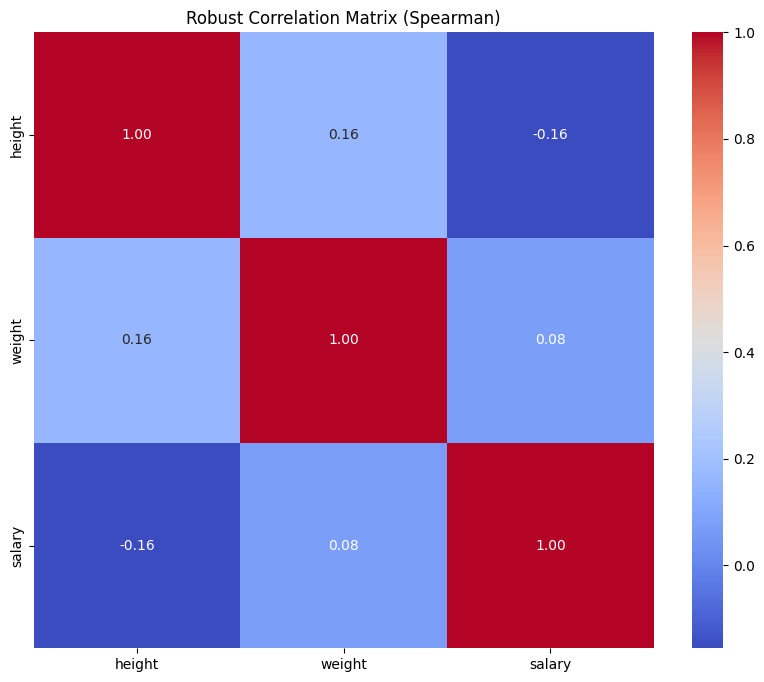

In [ ]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [ ]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [ ]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [ ]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

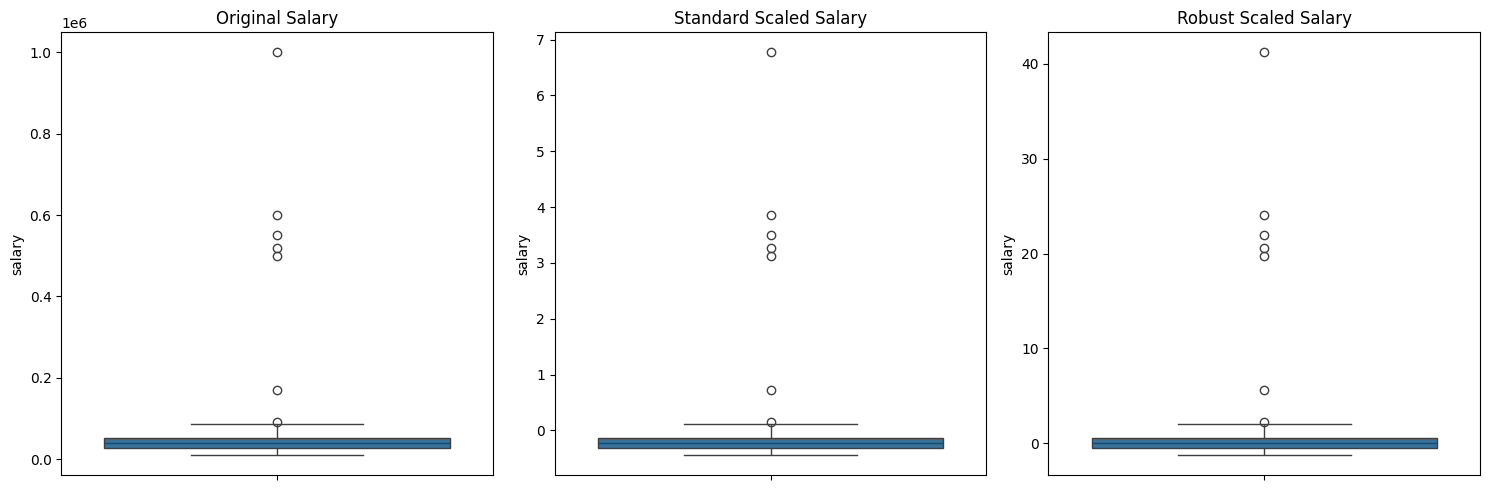

In [ ]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [ ]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.57x + 1.40')

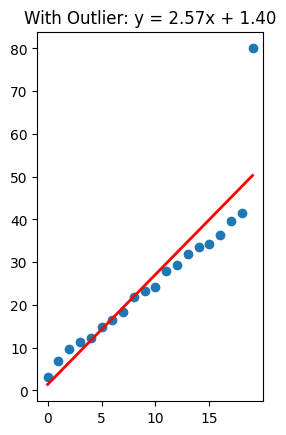

In [ ]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


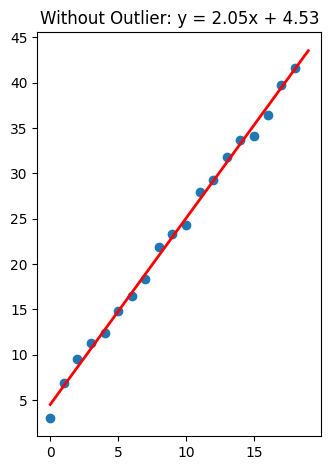

In [ ]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [ ]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


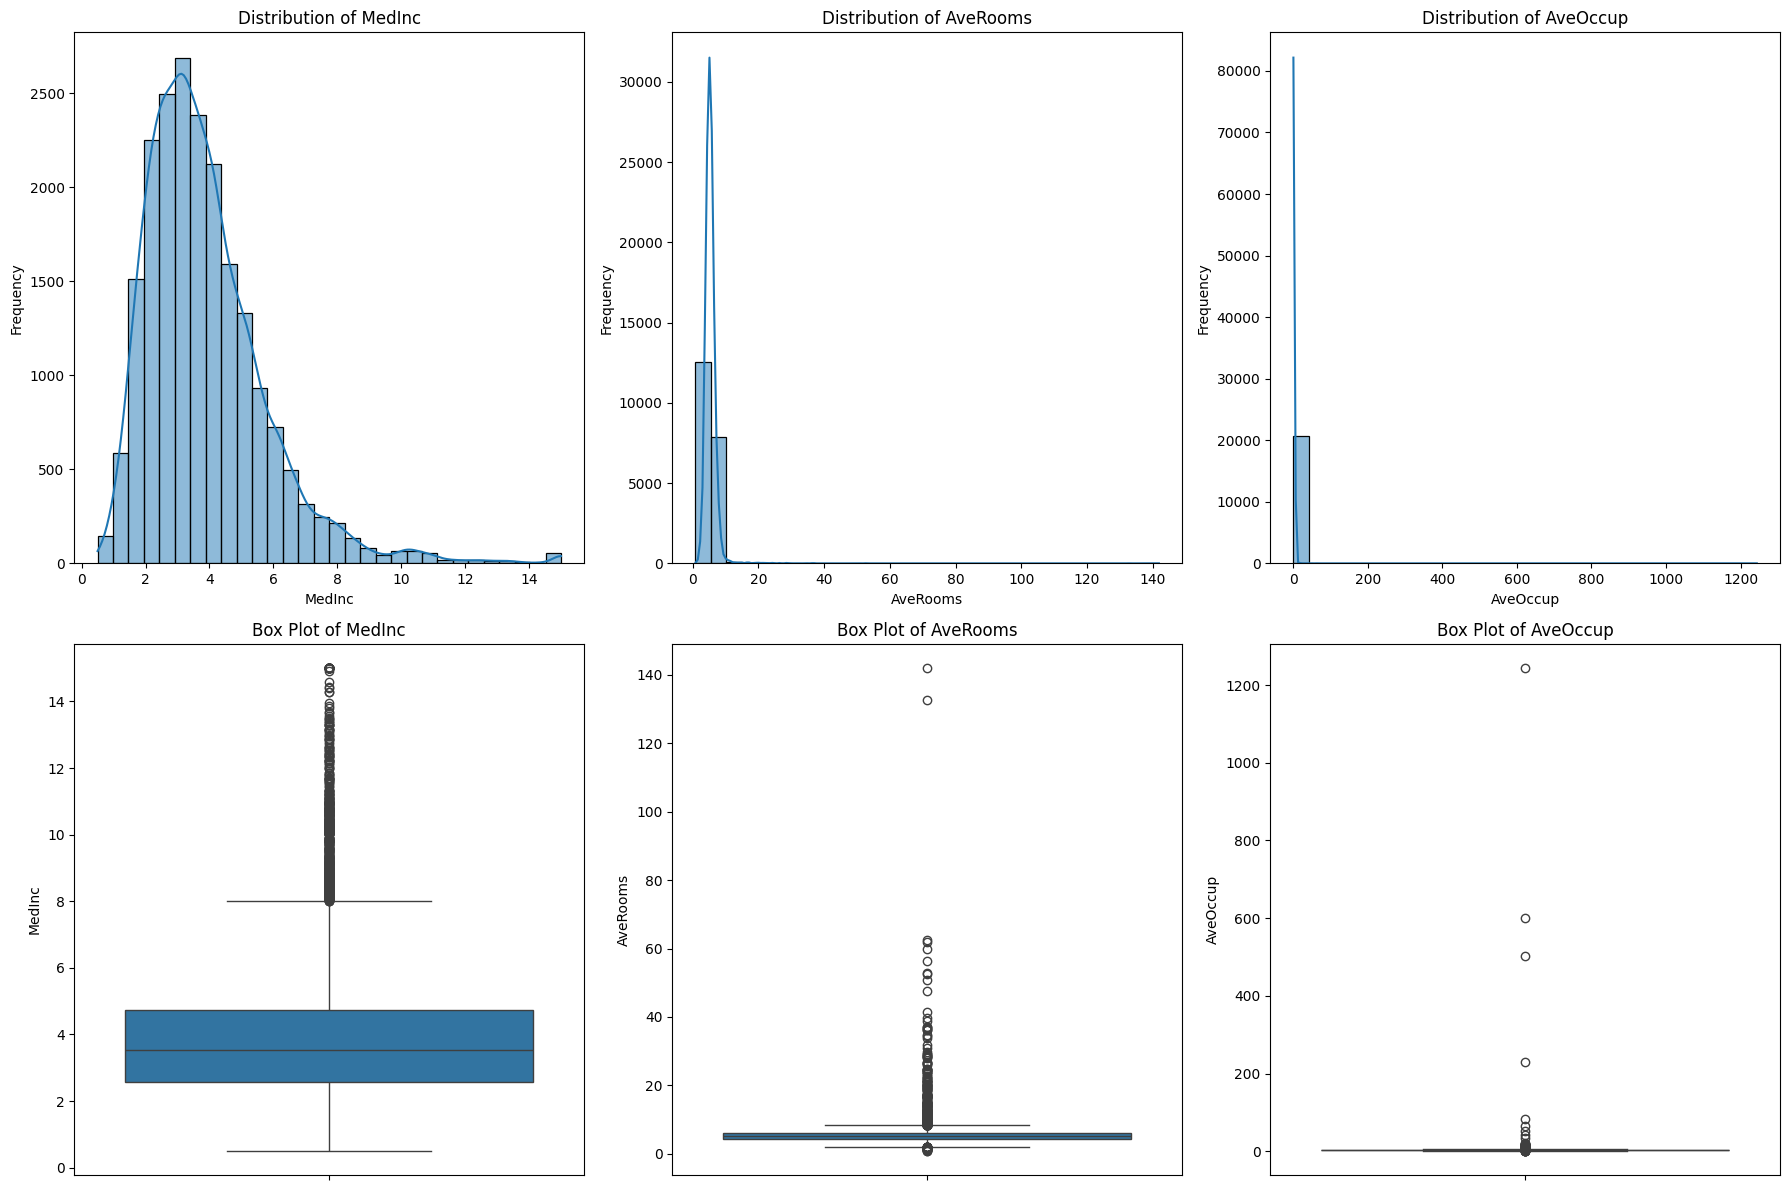


Summary Statistics for Selected Features:
             MedInc      AveRooms      AveOccup
count  20640.000000  20640.000000  20640.000000
mean       3.870671      5.429000      3.070655
std        1.899822      2.474173     10.386050
min        0.499900      0.846154      0.692308
25%        2.563400      4.440716      2.429741
50%        3.534800      5.229129      2.818116
75%        4.743250      6.052381      3.282261
max       15.000100    141.909091   1243.333333


In [5]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------
# TODO: Create histograms and boxplots for at least 3 features to visually identify outliers
# Hint: Use subplot to organize multiple plots


# Select 3 features to analyze for outliers
features_to_plot = ['MedInc', 'AveRooms', 'AveOccup']

# Create figure with subplots
plt.figure(figsize=(18, 12))

# Create histograms for the 3 features
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

# Create boxplots for the 3 features to visually identify outliers
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i+3)
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

# Display summary statistics to spot outliers numerically
print("\nSummary Statistics for Selected Features:")
print(df[features_to_plot].describe())

Z-score outliers in MedHouseVal: 0 found at indices []
IQR outliers in MedHouseVal: 1071 found at indices [   89   140   459 ... 20427 20436 20443]


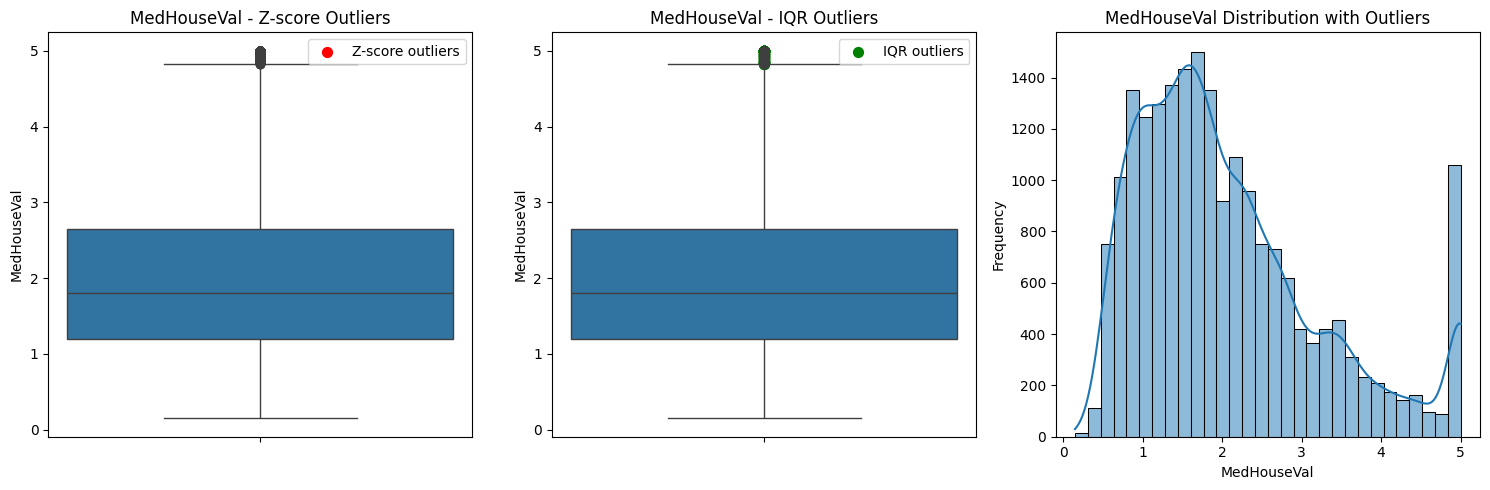


Outliers detected by BOTH methods: 0
Indices: []


In [6]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------
# TODO: Implement both Z-score and IQR outlier detection for the MedHouseVal feature

# Your implementation here

def detect_outliers_zscore(data, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]

def detect_outliers_iqr(data, factor=1.5):
    """Detect outliers using IQR method"""
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]

# Apply Z-score detection on MedHouseVal
z_outliers = detect_outliers_zscore(df['MedHouseVal'])
print(f"Z-score outliers in MedHouseVal: {len(z_outliers)} found at indices {z_outliers}")

# Apply IQR detection on MedHouseVal
iqr_outliers = detect_outliers_iqr(df['MedHouseVal'])
print(f"IQR outliers in MedHouseVal: {len(iqr_outliers)} found at indices {iqr_outliers}")

# Visualize the outliers
plt.figure(figsize=(15, 5))

# Box plot with Z-score outliers
plt.subplot(1, 3, 1)
sns.boxplot(y=df['MedHouseVal'])
plt.scatter(np.zeros_like(z_outliers), df['MedHouseVal'].iloc[z_outliers],
            color='red', s=50, label='Z-score outliers')
plt.title('MedHouseVal - Z-score Outliers')
plt.legend()

# Box plot with IQR outliers
plt.subplot(1, 3, 2)
sns.boxplot(y=df['MedHouseVal'])
plt.scatter(np.zeros_like(iqr_outliers), df['MedHouseVal'].iloc[iqr_outliers],
            color='green', s=50, label='IQR outliers')
plt.title('MedHouseVal - IQR Outliers')
plt.legend()

# Histogram showing outliers
plt.subplot(1, 3, 3)
sns.histplot(df['MedHouseVal'], kde=True, bins=30)
plt.title('MedHouseVal Distribution with Outliers')
plt.xlabel('MedHouseVal')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Show overlap between methods
common_outliers = set(z_outliers) & set(iqr_outliers)
print(f"\nOutliers detected by BOTH methods: {len(common_outliers)}")
print(f"Indices: {sorted(common_outliers)}")

Isolation Forest found 1032 outliers
Outlier indices: [ 59  63  73  87  89  91  92  95 155 192]...


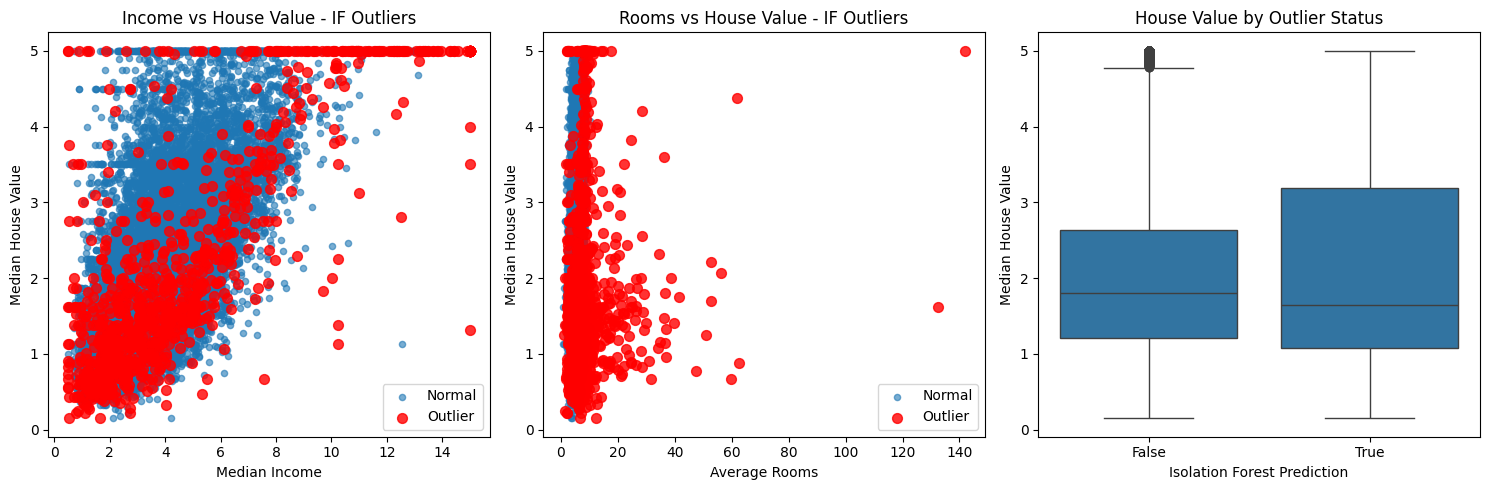


Comparison of Normal vs Outlier Points:
              MedInc  AveRooms  MedHouseVal
IF_Outlier                                 
False       3.815437  5.227859     2.059882
True        4.920108  9.250680     2.233409


In [7]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
# TODO: Implement the Isolation Forest algorithm to detect outliers in the dataset
# Use contamination=0.05 (assuming 5% of data points are outliers)
# Return a binary mask where -1 represents outliers

# Your implementation here

from sklearn.ensemble import IsolationForest

# Select all features for Isolation Forest
features_for_if = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                   'Population', 'AveOccup', 'Latitude', 'Longitude']
X_if = df[features_for_if]

# Create and fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest_pred = iso_forest.fit_predict(X_if)

# -1 means outlier, 1 means inlier (normal)
outlier_mask = iso_forest_pred == -1
if_outliers = np.where(outlier_mask)[0]

print(f"Isolation Forest found {len(if_outliers)} outliers")
print(f"Outlier indices: {if_outliers[:10]}...")

# Add outlier column to dataframe
df['IF_Outlier'] = outlier_mask

# Visualize the outliers
plt.figure(figsize=(15, 5))

# Scatter plot of Median Income vs House Value
plt.subplot(1, 3, 1)
normal_points = df[~outlier_mask]
outlier_points = df[outlier_mask]
plt.scatter(normal_points['MedInc'], normal_points['MedHouseVal'],
            alpha=0.6, label='Normal', s=20)
plt.scatter(outlier_points['MedInc'], outlier_points['MedHouseVal'],
            color='red', alpha=0.8, label='Outlier', s=50)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Income vs House Value - IF Outliers')
plt.legend()

# Scatter plot of AveRooms vs House Value
plt.subplot(1, 3, 2)
plt.scatter(normal_points['AveRooms'], normal_points['MedHouseVal'],
            alpha=0.6, label='Normal', s=20)
plt.scatter(outlier_points['AveRooms'], outlier_points['MedHouseVal'],
            color='red', alpha=0.8, label='Outlier', s=50)
plt.xlabel('Average Rooms')
plt.ylabel('Median House Value')
plt.title('Rooms vs House Value - IF Outliers')
plt.legend()

# Box plot showing outlier distribution
plt.subplot(1, 3, 3)
sns.boxplot(x=df['IF_Outlier'], y=df['MedHouseVal'])
plt.xlabel('Isolation Forest Prediction')
plt.ylabel('Median House Value')
plt.title('House Value by Outlier Status')

plt.tight_layout()
plt.show()

print("\nComparison of Normal vs Outlier Points:")
print(df.groupby('IF_Outlier')[['MedInc', 'AveRooms', 'MedHouseVal']].mean())

Model Performance Comparison:
             All Data  No Z-score Outliers  No IF Outliers
R2             0.4734               0.4734          0.4645
MSE            0.7011               0.7011          0.6845
Coefficient    0.4179               0.4179          0.4459
Intercept      0.4509               0.4509          0.3587


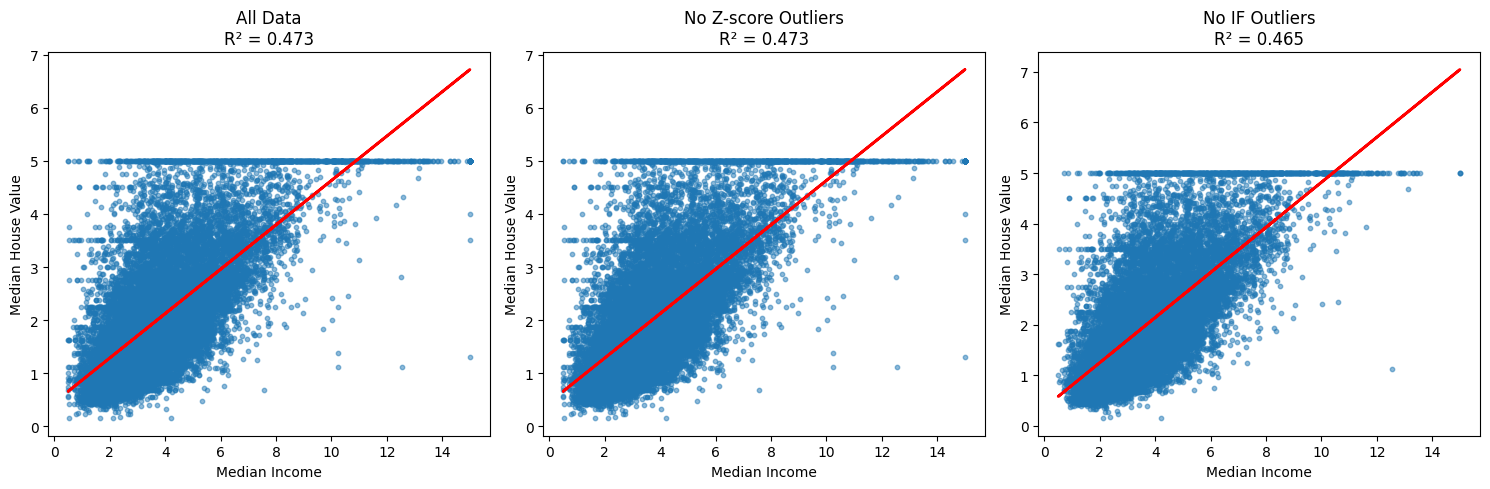


Original dataset size: 20640
Removed by Z-score: 0 (0.0%)
Removed by IF: 1032 (5.0%)


In [8]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------
# TODO:
# 1. Create a simple linear regression model using 'MedInc' to predict 'MedHouseVal'
# 2. Create 3 versions:
#    a. With all data
#    b. After removing Z-score outliers
#    c. After removing Isolation Forest outliers
# 3. Compare the model performance metrics (r2_score) and coefficients

# Your implementation here
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target
X_feature = df[['MedInc']]
y_target = df['MedHouseVal']

# 1. Model with ALL data
model_all = LinearRegression()
model_all.fit(X_feature, y_target)
y_pred_all = model_all.predict(X_feature)

# 2. Model WITHOUT Z-score outliers
z_outliers = detect_outliers_zscore(df['MedHouseVal'])
df_no_z = df.drop(z_outliers).copy()
X_no_z = df_no_z[['MedInc']]
y_no_z = df_no_z['MedHouseVal']
model_no_z = LinearRegression()
model_no_z.fit(X_no_z, y_no_z)
y_pred_no_z = model_no_z.predict(X_no_z)

# 3. Model WITHOUT Isolation Forest outliers
df_no_if = df[~df['IF_Outlier']].copy()
X_no_if = df_no_if[['MedInc']]
y_no_if = df_no_if['MedHouseVal']
model_no_if = LinearRegression()
model_no_if.fit(X_no_if, y_no_if)
y_pred_no_if = model_no_if.predict(X_no_if)

# Function to calculate metrics
def get_metrics(y_true, y_pred, model):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    coef = model.coef_[0]
    intercept = model.intercept_
    return {'R2': r2, 'MSE': mse, 'Coefficient': coef, 'Intercept': intercept}

# Calculate metrics for all models
metrics_all = get_metrics(y_target, y_pred_all, model_all)
metrics_no_z = get_metrics(y_no_z, y_pred_no_z, model_no_z)
metrics_no_if = get_metrics(y_no_if, y_pred_no_if, model_no_if)

# Create comparison table
comparison_df = pd.DataFrame({
    'All Data': metrics_all,
    'No Z-score Outliers': metrics_no_z,
    'No IF Outliers': metrics_no_if
})

print("Model Performance Comparison:")
print(comparison_df.round(4))

# Visualize the regression lines
plt.figure(figsize=(15, 5))

# 1. All Data
plt.subplot(1, 3, 1)
plt.scatter(X_feature, y_target, alpha=0.5, s=10)
plt.plot(X_feature, model_all.predict(X_feature), color='red', linewidth=2)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title(f'All Data\nR² = {metrics_all["R2"]:.3f}')

# 2. No Z-score Outliers
plt.subplot(1, 3, 2)
plt.scatter(X_no_z, y_no_z, alpha=0.5, s=10)
plt.plot(X_no_z, model_no_z.predict(X_no_z), color='red', linewidth=2)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title(f'No Z-score Outliers\nR² = {metrics_no_z["R2"]:.3f}')

# 3. No IF Outliers
plt.subplot(1, 3, 3)
plt.scatter(X_no_if, y_no_if, alpha=0.5, s=10)
plt.plot(X_no_if, model_no_if.predict(X_no_if), color='red', linewidth=2)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title(f'No IF Outliers\nR² = {metrics_no_if["R2"]:.3f}')

plt.tight_layout()
plt.show()

print(f"\nOriginal dataset size: {len(df)}")
print(f"Removed by Z-score: {len(z_outliers)} ({len(z_outliers)/len(df)*100:.1f}%)")
print(f"Removed by IF: {len(df) - len(df_no_if)} ({ (len(df) - len(df_no_if))/len(df)*100:.1f}%)")

In [ ]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------
# TODO: Create a custom outlier detection function that combines multiple methods
# It should:
# 1. Take a dataframe and column name as input
# 2. Apply at least 2 different outlier detection methods (of your choice)
# 3. Return the indices of consensus outliers (detected by both methods)
# 4. Include a visualization of the outliers

# Your implementation here

def custom_outlier_detection(data, feature_name, methods=['zscore', 'iqr']):
    """
    Custom function that combines multiple outlier detection methods

    Parameters:
    - data: DataFrame
    - feature_name: column to analyze
    - methods: list of methods to use ['zscore', 'iqr']

    Returns:
    - consensus_outliers: indices found by ALL methods
    """

    feature = data[feature_name]
    all_results = {}

    # Method 1: Z-score
    if 'zscore' in methods:
        z_scores = np.abs(stats.zscore(feature))
        z_outliers = np.where(z_scores > 3)[0]
        all_results['zscore'] = z_outliers

    # Method 2: IQR
    if 'iqr' in methods:
        q1, q3 = np.percentile(feature, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        iqr_outliers = np.where((feature < lower_bound) | (feature > upper_bound))[0]
        all_results['iqr'] = iqr_outliers

    # Find consensus outliers (detected by ALL methods)
    if len(all_results) >= 2:
        consensus = set(all_results[list(all_results.keys())[0]])
        for method in list(all_results.keys())[1:]:
            consensus = consensus & set(all_results[method])
        consensus_outliers = sorted(list(consensus))
    else:
        consensus_outliers = []

    # Visualization
    plt.figure(figsize=(15, 5))

    # Plot 1: Box plot with ALL outliers highlighted
    plt.subplot(1, 3, 1)
    sns.boxplot(y=feature)
    colors = ['red', 'green']
    for i, (method, indices) in enumerate(all_results.items()):
        plt.scatter(np.zeros_like(indices) + i*0.1 - 0.05,
                   feature.iloc[indices],
                   color=colors[i % len(colors)],
                   s=40, label=method, alpha=0.7)
    plt.title(f'{feature_name} - All Outlier Methods')
    plt.legend()

    # Plot 2: Consensus outliers
    plt.subplot(1, 3, 2)
    sns.boxplot(y=feature)
    if len(consensus_outliers) > 0:
        plt.scatter(np.zeros_like(consensus_outliers),
                   feature.iloc[consensus_outliers],
                   color='purple', s=80, label='Consensus Outliers')
    plt.title(f'Consensus Outliers: {len(consensus_outliers)}')
    plt.legend()

    # Plot 3: Histogram with outliers
    plt.subplot(1, 3, 3)
    sns.histplot(feature, kde=True, bins=30)
    if len(consensus_outliers) > 0:
        for idx in consensus_outliers:
            plt.axvline(x=feature.iloc[idx], color='purple', alpha=0.3, linestyle='--')
    plt.title(f'{feature_name} Distribution with Outliers')

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n=== Outlier Detection Summary for {feature_name} ===")
    print(f"Total data points: {len(feature)}")
    print("\nOutliers found by each method:")
    for method, indices in all_results.items():
        print(f"  {method}: {len(indices)} outliers ({len(indices)/len(feature)*100:.1f}%)")
    print(f"\nConsensus outliers: {len(consensus_outliers)}")

    return consensus_outliers, all_results

# Test the function
consensus_outliers, all_results = custom_outlier_detection(
    df, 'MedHouseVal', methods=['zscore', 'iqr']
)

print(f"\nConsensus outliers indices: {consensus_outliers[:20]}")

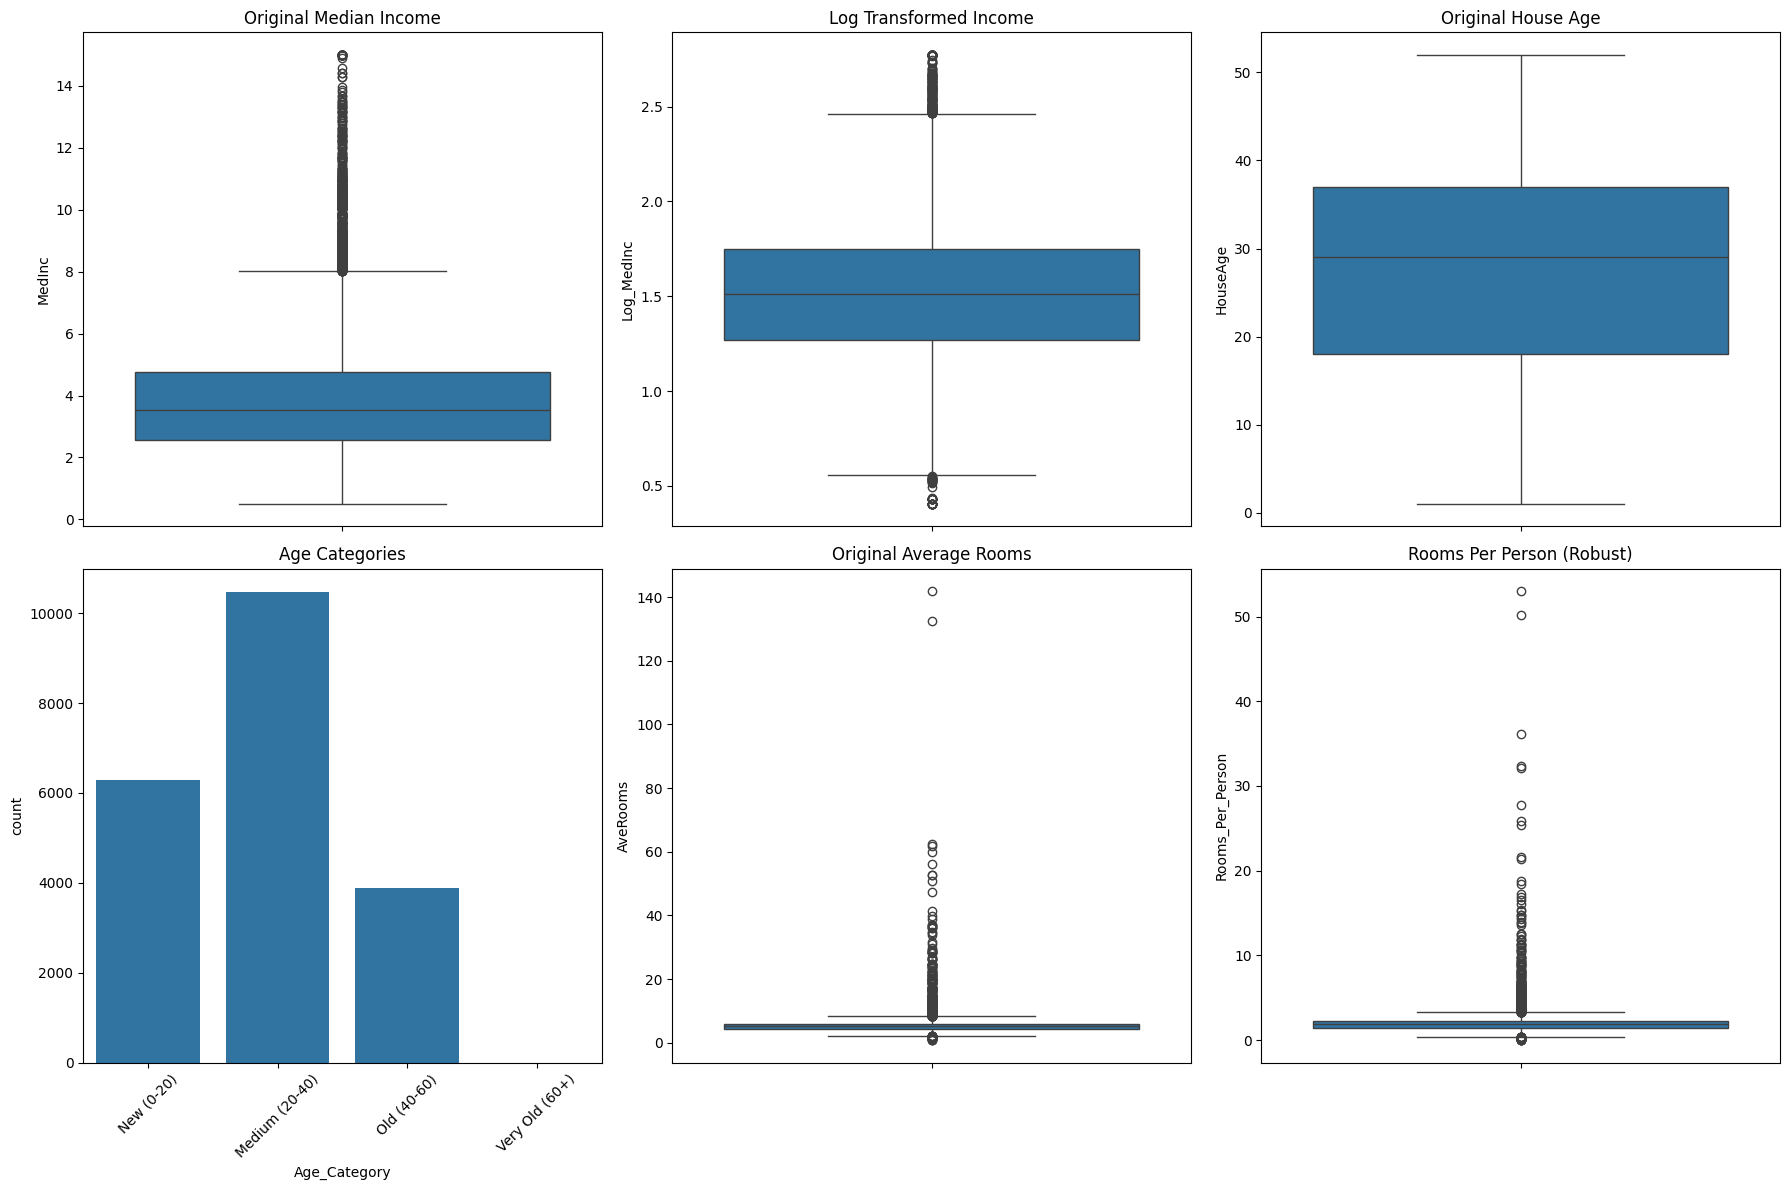

Comparison of Original vs Transformed Features:

Median Income:
  Original: Mean=3.871, Skew=1.647
  Log Transformed: Mean=1.517, Skew=0.226

Correlation with House Value:
  Original MedInc: 0.688
  Log MedInc: 0.670
  Rooms Per Person: 0.210


In [9]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------
# TODO: Create a new feature that is more robust to outliers
# Suggestions:
# - Use log transformation
# - Use binning/discretization
# - Create a ratio or interaction feature
# Compare the distribution before and after your transformation

# Your implementation here

# Create a copy for feature engineering
df_fe = df.copy()

# 1. LOG TRANSFORMATION - Makes data more normal and reduces outlier impact
df_fe['Log_MedInc'] = np.log(df_fe['MedInc'] + 1)

# 2. BINNING - Groups continuous values into categories
df_fe['Age_Category'] = pd.cut(df_fe['HouseAge'],
                               bins=[0, 20, 40, 60, 80],
                               labels=['New (0-20)', 'Medium (20-40)',
                                      'Old (40-60)', 'Very Old (60+)'])

# 3. RATIO FEATURE - More meaningful than individual features
df_fe['Rooms_Per_Person'] = df_fe['AveRooms'] / (df_fe['AveOccup'] + 0.1)

# Compare distributions before and after transformation
plt.figure(figsize=(18, 12))

# Original MedInc vs Log_MedInc
plt.subplot(2, 3, 1)
sns.boxplot(y=df_fe['MedInc'])
plt.title('Original Median Income')

plt.subplot(2, 3, 2)
sns.boxplot(y=df_fe['Log_MedInc'])
plt.title('Log Transformed Income')

# Original HouseAge vs Age_Category
plt.subplot(2, 3, 3)
sns.boxplot(y=df_fe['HouseAge'])
plt.title('Original House Age')

plt.subplot(2, 3, 4)
sns.countplot(x=df_fe['Age_Category'])
plt.title('Age Categories')
plt.xticks(rotation=45)

# Original AveRooms vs Rooms_Per_Person
plt.subplot(2, 3, 5)
sns.boxplot(y=df_fe['AveRooms'])
plt.title('Original Average Rooms')

plt.subplot(2, 3, 6)
sns.boxplot(y=df_fe['Rooms_Per_Person'])
plt.title('Rooms Per Person (Robust)')

plt.tight_layout()
plt.show()

# Compare statistics
print("Comparison of Original vs Transformed Features:")
print("\nMedian Income:")
print(f"  Original: Mean={df_fe['MedInc'].mean():.3f}, Skew={stats.skew(df_fe['MedInc']):.3f}")
print(f"  Log Transformed: Mean={df_fe['Log_MedInc'].mean():.3f}, Skew={stats.skew(df_fe['Log_MedInc']):.3f}")

print("\nCorrelation with House Value:")
print(f"  Original MedInc: {df_fe['MedInc'].corr(df_fe['MedHouseVal']):.3f}")
print(f"  Log MedInc: {df_fe['Log_MedInc'].corr(df_fe['MedHouseVal']):.3f}")
print(f"  Rooms Per Person: {df_fe['Rooms_Per_Person'].corr(df_fe['MedHouseVal']):.3f}")

Multivariate outliers found: 37
Threshold value: 9.488
Outlier indices: [ 1024  1102  1234  1238  1239  1240  1872  1912  1913  1914  1926  1978
  1979  2395  2397  3086  3364  9676  9683 10080]


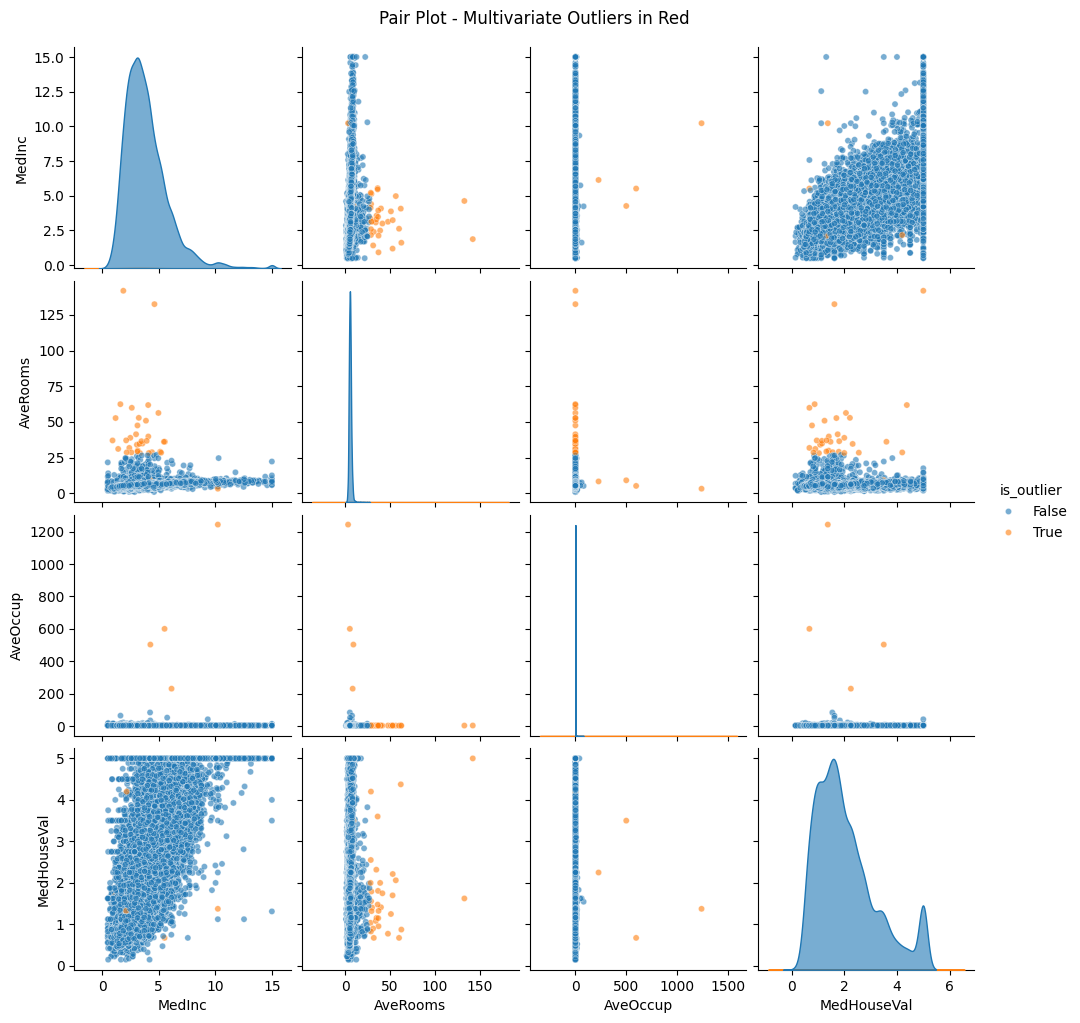

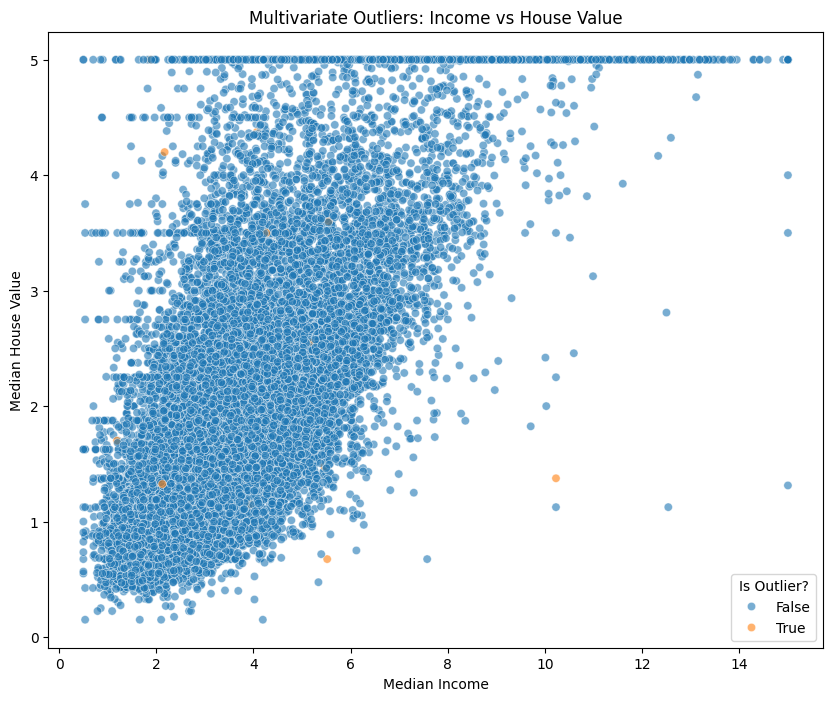


Mahalanobis Distance Statistics:
Min distance: 0.049
Max distance: 119.440
Mean distance: 1.320
Std distance: 1.503


In [10]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------
# TODO: Implement a multivariate outlier detection method using Mahalanobis distance
# Calculate the distance for each point and identify outliers using a chi-squared threshold
# Visualize the results using a scatter plot matrix highlighting the outliers

# Your implementation here

from scipy.stats import chi2

def detect_multivariate_outliers(data, threshold=0.95):
    """
    Detect multivariate outliers using Mahalanobis distance
    """
    # Convert to array
    X = data.values

    # Calculate mean vector
    mean_vec = np.mean(X, axis=0)

    # Calculate covariance matrix
    cov_matrix = np.cov(X, rowvar=False)
    inv_cov_matrix = np.linalg.inv(cov_matrix)

    # Calculate Mahalanobis distance for each point
    mahal_dist = []
    for i in range(len(X)):
        diff = X[i] - mean_vec
        mahal = np.sqrt(diff.dot(inv_cov_matrix).dot(diff.T))
        mahal_dist.append(mahal)

    mahal_dist = np.array(mahal_dist)

    # Find threshold using chi-squared distribution
    df_features = X.shape[1]
    threshold_value = chi2.ppf(threshold, df_features)

    # Find outliers
    outlier_indices = np.where(mahal_dist > threshold_value)[0]

    return outlier_indices, mahal_dist, threshold_value

# Select features for multivariate analysis
features_for_mahalanobis = ['MedInc', 'AveRooms', 'AveOccup', 'MedHouseVal']
X_mahal = df[features_for_mahalanobis]

# Apply multivariate outlier detection
mahal_outliers, mahal_dist, threshold_value = detect_multivariate_outliers(X_mahal, threshold=0.95)

print(f"Multivariate outliers found: {len(mahal_outliers)}")
print(f"Threshold value: {threshold_value:.3f}")
print(f"Outlier indices: {mahal_outliers[:20]}")

# Visualize using pair plot
import matplotlib.pyplot as plt
import seaborn as sns

# Create a column to identify outliers
df_mahal = df.copy()
df_mahal['is_outlier'] = False
df_mahal.loc[mahal_outliers, 'is_outlier'] = True

# Pair plot highlighting outliers
sns.pairplot(df_mahal[features_for_mahalanobis + ['is_outlier']],
             hue='is_outlier',
             diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 20},
             diag_kws={'alpha': 0.6})
plt.suptitle('Pair Plot - Multivariate Outliers in Red', y=1.02)
plt.show()

# Scatter plot with outliers highlighted
plt.figure(figsize=(10, 8))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df_mahal,
                hue='is_outlier', alpha=0.6)
plt.title('Multivariate Outliers: Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend(title='Is Outlier?')
plt.show()

print("\nMahalanobis Distance Statistics:")
print(f"Min distance: {mahal_dist.min():.3f}")
print(f"Max distance: {mahal_dist.max():.3f}")
print(f"Mean distance: {mahal_dist.mean():.3f}")
print(f"Std distance: {mahal_dist.std():.3f}")
